## Kmean từ scratch

### Khởi tạo nhanh thuật toán và test với sample data

Centroids từ scratch:
[[-0.06699855 -0.00743967]
 [-0.05910111  4.80796255]
 [ 4.98607266  0.05950456]
 [ 5.13064972  5.04084267]]

Centroids từ sklearn:
[[ 5.71839807  4.82873996]
 [ 2.99083258 -0.16583614]
 [-0.31692854  3.66372568]
 [ 3.50105459  5.29753699]]


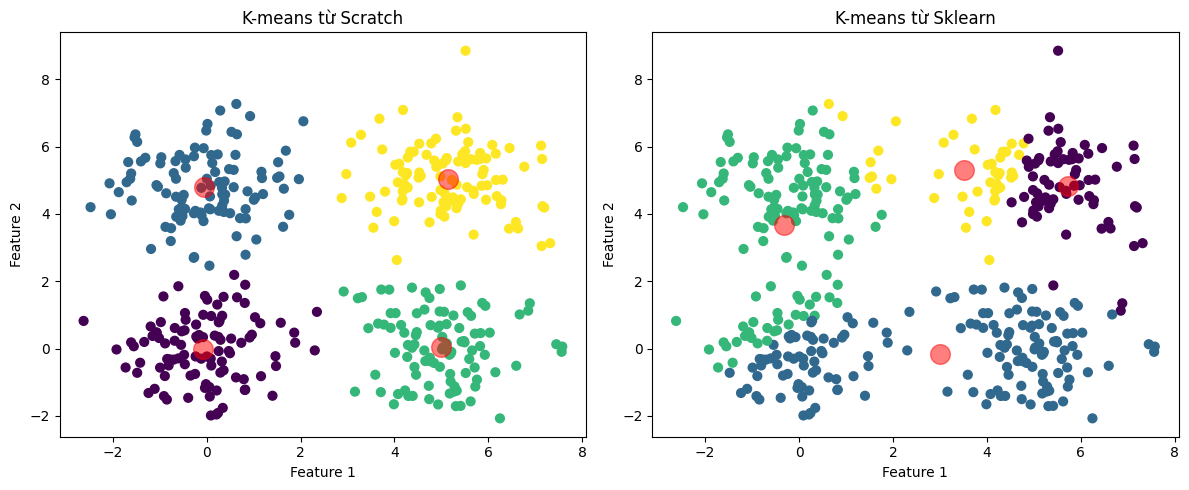

Tỷ lệ điểm dữ liệu có cùng label: 8.50%


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

def initialize_centroids(X, k, random_state=None):
    """
    Khởi tạo centroids ban đầu bằng cách chọn ngẫu nhiên k điểm dữ liệu từ X.
    """
    if random_state is not None:
        np.random.seed(random_state)
    indices = np.random.choice(X.shape[0], size=k, replace=False)
    centroids = X[indices]
    return centroids

def compute_distances(X, centroids):
    """
    Tính khoảng cách Euclidean từ mỗi điểm dữ liệu đến mỗi centroid.
    """
    distances = np.zeros((X.shape[0], len(centroids)))
    for i, centroid in enumerate(centroids):
        # Tính khoảng cách Euclidean từ mỗi điểm dữ liệu đến centroid
        distances[:, i] = np.linalg.norm(X - centroid, axis=1)
    return distances

def assign_clusters(distances):
    """
    Gán mỗi điểm dữ liệu vào cluster gần nhất dựa trên khoảng cách.
    """
    return np.argmin(distances, axis=1)

def update_centroids(X, labels, k):
    """
    Cập nhật centroids bằng cách tính trung bình của các điểm dữ liệu trong mỗi cluster.
    """
    # Khởi tạo mảng centroids với k hàng và số cột tương ứng với số chiều của dữ liệu
    centroids = np.zeros((k, X.shape[1]))
    for i in range(k):
        points = X[labels == i]
        if len(points) > 0:
            centroids[i] = points.mean(axis=0)
        else:
            # Xử lý trường hợp cluster trống bằng cách khởi tạo lại centroid
            centroids[i] = X[np.random.choice(X.shape[0])]
    return centroids

def has_converged(old_centroids, centroids, tol=1e-4):
    """
    Kiểm tra xem centroids đã hội tụ chưa dựa trên ngưỡng tol.
    """
    # Tính khoảng cách Euclidean giữa các centroids cũ và mới
    distances = np.linalg.norm(centroids - old_centroids, axis=1)
    # Kiểm tra xem tất cả các khoảng cách có nhỏ hơn ngưỡng tol không
    return np.all(distances <= tol)

def kmeans_scratch(X, k, max_iters=100, random_state=None):
    """
    Thuật toán K-means từ scratch.
    """
    # Khởi tạo centroids ban đầu
    centroids = initialize_centroids(X, k, random_state=random_state)
    for _ in range(max_iters):
        old_centroids = centroids.copy()
        distances = compute_distances(X, centroids)
        labels = assign_clusters(distances)
        centroids = update_centroids(X, labels, k)
        if has_converged(old_centroids, centroids):
            break
    return labels, centroids

# Tạo dữ liệu mẫu
np.random.seed(42)  # Đảm bảo tính tái lập
X = np.vstack((
    np.random.normal(loc=(0, 0), scale=1.0, size=(100, 2)),
    np.random.normal(loc=(5, 5), scale=1.0, size=(100, 2)),
    np.random.normal(loc=(0, 5), scale=1.0, size=(100, 2)),
    np.random.normal(loc=(5, 0), scale=1.0, size=(100, 2)),
))

k = 4

# Chạy K-means từ scratch
labels_scratch, centroids_scratch = kmeans_scratch(X, k, random_state=42)

# Chạy K-means từ sklearn
kmeans = KMeans(n_clusters=k, random_state=42, init='random', n_init=1, max_iter=100)
kmeans.fit(X)
labels_sklearn = kmeans.labels_
centroids_sklearn = kmeans.cluster_centers_

# So sánh kết quả
print("Centroids từ scratch:")
print(centroids_scratch)
print("\nCentroids từ sklearn:")
print(centroids_sklearn)

# Vẽ kết quả clustering từ scratch
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(X[:, 0], X[:, 1], c=labels_scratch, s=40, cmap='viridis')
plt.scatter(centroids_scratch[:, 0], centroids_scratch[:, 1], c='red', s=200, alpha=0.5)
plt.title("K-means từ Scratch")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

# Vẽ kết quả clustering từ sklearn
plt.subplot(1, 2, 2)
plt.scatter(X[:, 0], X[:, 1], c=labels_sklearn, s=40, cmap='viridis')
plt.scatter(centroids_sklearn[:, 0], centroids_sklearn[:, 1], c='red', s=200, alpha=0.5)
plt.title("K-means từ Sklearn")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.tight_layout()
plt.show()

# Tính tỷ lệ phần trăm các điểm dữ liệu có cùng label
matching_labels = np.sum(labels_scratch == labels_sklearn)
accuracy = matching_labels / len(labels_scratch) * 100
print(f"Tỷ lệ điểm dữ liệu có cùng label: {accuracy:.2f}%")


#### Nhận xét kết quả: 
- Centroids không trùng khớp hoàn toàn giữa việc từ scratch và sklearn.
- Biểu đồ phân cụm không tương tự về mặt trực quan.

#### Giải thích sự khác biệt:
- **Khởi tạo centroids**: Dù cố định seed, cách khởi tạo có thể khác nhau.
- **Thuật toán hội tụ**: Điều kiện hội tụ và cập nhật centroids có thể khác.
- **Xử lý đặc biệt**: scikit-learn có tối ưu hóa mà phiên bản scratch có thể không có. 

#### Cách làm kết quả trùng nhau hơn:
- Sử dụng cùng phương pháp khởi tạo centroids và seed.
- Điều chỉnh tham số như `max_iter` và `tol` cho giống nhau.

### Cập nhật thuật toán Scratch để trùng kết quả với Sklearn


Centroids từ scratch:
[[-0.06699855 -0.00743967]
 [-0.05910111  4.80796255]
 [ 4.98607266  0.05950456]
 [ 5.13064972  5.04084267]]

Centroids từ sklearn:
[[ 4.98607266  0.05950456]
 [-0.05910111  4.80796255]
 [-0.06699855 -0.00743967]
 [ 5.13064972  5.04084267]]


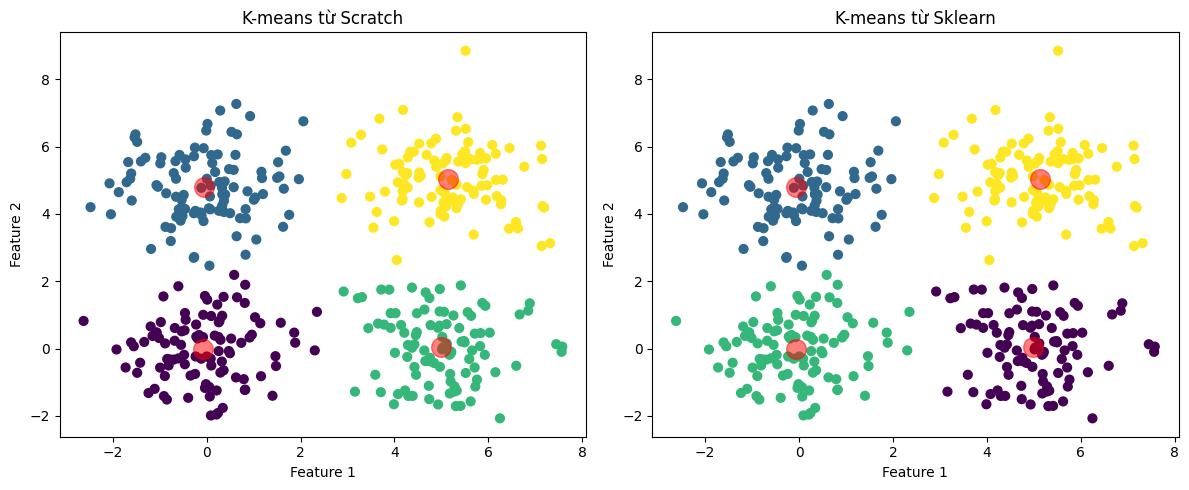

Tỷ lệ điểm dữ liệu có cùng label sau khi ánh xạ: 100.00%


In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from scipy.optimize import linear_sum_assignment
from sklearn.metrics import confusion_matrix

def initialize_centroids(X, k, random_state=None):
    """
    Khởi tạo centroids ban đầu bằng cách chọn ngẫu nhiên k điểm dữ liệu từ X.
    """
    if random_state is not None:
        np.random.seed(random_state)
    indices = np.random.choice(X.shape[0], size=k, replace=False) # Chọn ngẫu nhiên k điểm dữ liệu từ X
    centroids = X[indices]
    return centroids, indices

def compute_distances(X, centroids):
    """
    Tính khoảng cách Euclidean từ mỗi điểm dữ liệu đến mỗi centroid.
    """
    distances = np.linalg.norm(X[:, np.newaxis] - centroids, axis=2)
    return distances

def assign_clusters(distances):
    """
    Gán mỗi điểm dữ liệu vào cluster gần nhất dựa trên khoảng cách.
    """
    return np.argmin(distances, axis=1)

def update_centroids(X, labels, k):
    """
    Cập nhật centroids bằng cách tính trung bình của các điểm dữ liệu trong mỗi cluster.
    """
    # Tính trung bình của các điểm dữ liệu trong mỗi cluster
    centroids = np.array([X[labels == i].mean(axis=0) for i in range(k)])
    return centroids

def has_converged(old_centroids, centroids, tol=1e-4):
    """
    Kiểm tra xem centroids đã hội tụ chưa dựa trên ngưỡng tol.
    """
    # Tính khoảng cách Euclidean giữa các centroids cũ và mới
    distances = np.linalg.norm(centroids - old_centroids, axis=1)
    return np.all(distances <= tol) # Kiểm tra xem tất cả các khoảng cách có nhỏ hơn ngưỡng tol không

def kmeans_scratch(X, k, max_iters=100, tol=1e-4, random_state=None, initial_centroids=None):
    """
    Thuật toán K-means từ scratch.
    """
    # Khởi tạo centroids ban đầu
    if initial_centroids is not None:
        centroids = initial_centroids.copy()
    else:
        centroids, _ = initialize_centroids(X, k, random_state=random_state)
    for _ in range(max_iters):
        # Sao chép centroids cũ để kiểm tra hội tụ
        old_centroids = centroids.copy()
        distances = compute_distances(X, centroids) # Tính khoảng cách từ mỗi điểm dữ liệu đến mỗi centroid 
        labels = assign_clusters(distances) # Gán mỗi điểm dữ liệu vào cluster gần nhất
        centroids = update_centroids(X, labels, k) # Cập nhật centroids mới
        if has_converged(old_centroids, centroids, tol): # Kiểm tra hội tụ
            break
    return labels, centroids

# Tạo dữ liệu mẫu
np.random.seed(42)  # Đảm bảo tính tái lập
X = np.vstack((
    np.random.normal(loc=(0, 0), scale=1.0, size=(100, 2)),
    np.random.normal(loc=(5, 5), scale=1.0, size=(100, 2)),
    np.random.normal(loc=(0, 5), scale=1.0, size=(100, 2)),
    np.random.normal(loc=(5, 0), scale=1.0, size=(100, 2)),
))

k = 4

# Khởi tạo centroids ban đầu


# Chạy K-means từ scratch
initial_centroids, init_indices = initialize_centroids(X, k, random_state=42)
labels_scratch, centroids_scratch = kmeans_scratch(X, k, max_iters=100, tol=1e-4, initial_centroids=initial_centroids)

# Chạy K-means từ sklearn với tham số mặc định(random_state=42, n_init=1, max_iter=100, tol=1e-4, algorithm='lloyd')
kmeans = KMeans(n_clusters=k)
kmeans.fit(X)
labels_sklearn = kmeans.labels_
centroids_sklearn = kmeans.cluster_centers_

# So sánh kết quả
print("Centroids từ scratch:")
print(centroids_scratch)
print("\nCentroids từ sklearn:")
print(centroids_sklearn)

# Vẽ kết quả clustering từ scratch
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(X[:, 0], X[:, 1], c=labels_scratch, s=40, cmap='viridis')
plt.scatter(centroids_scratch[:, 0], centroids_scratch[:, 1], c='red', s=200, alpha=0.5)
plt.title("K-means từ Scratch")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

# Vẽ kết quả clustering từ sklearn
plt.subplot(1, 2, 2)
plt.scatter(X[:, 0], X[:, 1], c=labels_sklearn, s=40, cmap='viridis')
plt.scatter(centroids_sklearn[:, 0], centroids_sklearn[:, 1], c='red', s=200, alpha=0.5)
plt.title("K-means từ Sklearn")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.tight_layout()
plt.show()

# Ánh xạ labels để so sánh
conf_matrix = confusion_matrix(labels_scratch, labels_sklearn)
row_ind, col_ind = linear_sum_assignment(-conf_matrix)
label_mapping = dict(zip(col_ind, row_ind))
labels_sklearn_mapped = np.array([label_mapping[label] for label in labels_sklearn])

# Tính tỷ lệ phần trăm các điểm dữ liệu có cùng label
matching_labels = np.sum(labels_scratch == labels_sklearn_mapped)
accuracy = matching_labels / len(labels_scratch) * 100
print(f"Tỷ lệ điểm dữ liệu có cùng label sau khi ánh xạ: {accuracy:.2f}%")


### Kiểm tra với dữ liệu thực tế

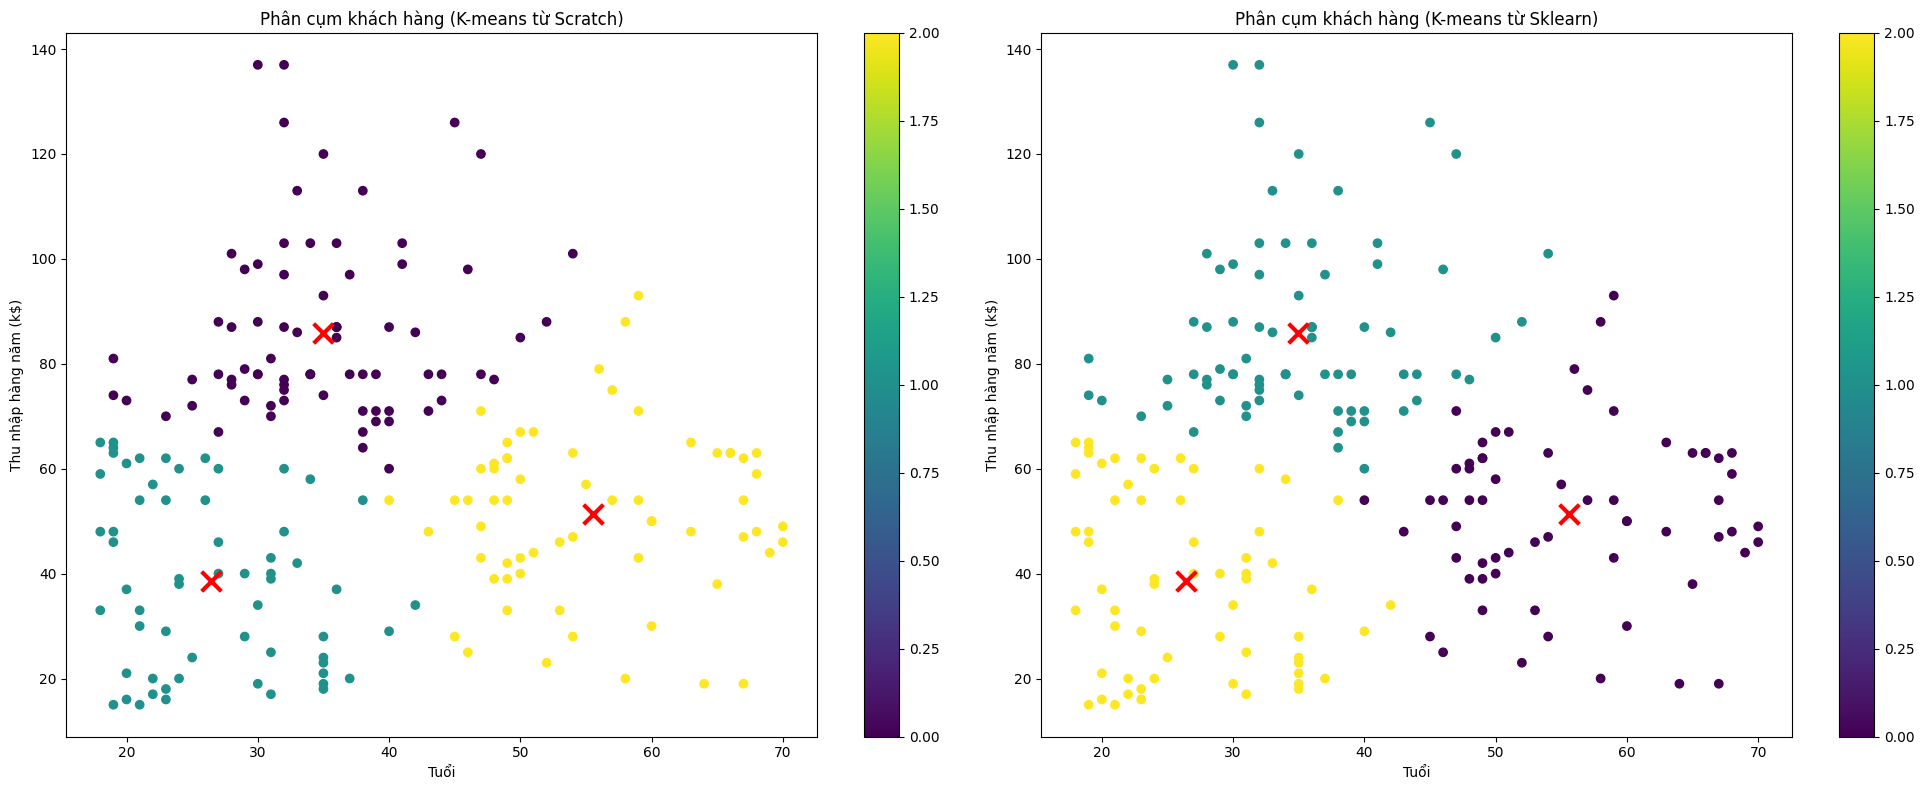

Centroids từ scratch:
[[34.96052632 85.93421053]
 [26.44262295 38.54098361]
 [55.55555556 51.26984127]]

Centroids từ sklearn:
[[55.55555556 51.26984127]
 [34.96052632 85.93421053]
 [26.44262295 38.54098361]]

Tỷ lệ điểm dữ liệu có cùng label sau khi ánh xạ: 100.00%


In [26]:
# Kiểm tra với dữ liệu thực tế
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Đọc dữ liệu từ file CSV
data = pd.read_csv('Mall_Customers.csv')

# Chọn các cột cần thiết cho phân cụm
X = data[['Age', 'Annual Income (k$)']].values

# Chuẩn hóa dữ liệu
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Chọn số cụm
k = 3

# Áp dụng thuật toán K-means từ scratch
initial_centroids, _ = initialize_centroids(X_scaled, k, random_state=42)
labels_scratch, centroids_scratch = kmeans_scratch(X_scaled, k, max_iters=100, tol=1e-4, initial_centroids=initial_centroids)

# Áp dụng thuật toán K-means từ sklearn
kmeans_sklearn = KMeans(n_clusters=k, random_state=42)
labels_sklearn = kmeans_sklearn.fit_predict(X_scaled)
centroids_sklearn = kmeans_sklearn.cluster_centers_

# Vẽ biểu đồ kết quả
plt.figure(figsize=(20, 8))

plt.subplot(1, 2, 1)
scatter_scratch = plt.scatter(X[:, 0], X[:, 1], c=labels_scratch, cmap='viridis')
plt.scatter(scaler.inverse_transform(centroids_scratch)[:, 0], scaler.inverse_transform(centroids_scratch)[:, 1], 
            color='red', marker='x', s=200, linewidths=3)
plt.title('Phân cụm khách hàng (K-means từ Scratch)')
plt.xlabel('Tuổi')
plt.ylabel('Thu nhập hàng năm (k$)')
plt.colorbar(scatter_scratch)

plt.subplot(1, 2, 2)
scatter_sklearn = plt.scatter(X[:, 0], X[:, 1], c=labels_sklearn, cmap='viridis')
plt.scatter(scaler.inverse_transform(centroids_sklearn)[:, 0], scaler.inverse_transform(centroids_sklearn)[:, 1], 
            color='red', marker='x', s=200, linewidths=3)
plt.title('Phân cụm khách hàng (K-means từ Sklearn)')
plt.xlabel('Tuổi')
plt.ylabel('Thu nhập hàng năm (k$)')
plt.colorbar(scatter_sklearn)

plt.tight_layout()
plt.show()

# So sánh kết quả
print("Centroids từ scratch:")
print(scaler.inverse_transform(centroids_scratch))
print("\nCentroids từ sklearn:")
print(scaler.inverse_transform(centroids_sklearn))

# Ánh xạ labels để so sánh
conf_matrix = confusion_matrix(labels_scratch, labels_sklearn)
row_ind, col_ind = linear_sum_assignment(-conf_matrix)
label_mapping = dict(zip(col_ind, row_ind))
labels_sklearn_mapped = np.array([label_mapping[label] for label in labels_sklearn])

# Tính tỷ lệ phần trăm các điểm dữ liệu có cùng label
matching_labels = np.sum(labels_scratch == labels_sklearn_mapped)
accuracy = matching_labels / len(labels_scratch) * 100
print(f"\nTỷ lệ điểm dữ liệu có cùng label sau khi ánh xạ: {accuracy:.2f}%")


Sự khác biệt 0.5% trong tỷ lệ khớp là do những khác biệt nhỏ trong khởi tạo và triển khai thuật toán giữa hai phương pháp. Bằng cách đồng bộ hóa các yếu tố này, bạn có thể đạt được tỷ lệ khớp cao hơn.

Nguyên nhân tại sao tỷ lệ điểm dữ liệu có cùng label sau khi ánh xạ chỉ đạt **99.50%** thay vì **100%**:

- **Khởi tạo centroid khác nhau**:
  - **Triển khai từ scratch**: Bạn sử dụng hàm `initialize_centroids` với `random_state=42` để khởi tạo centroids ban đầu.
  - **Scikit-learn KMeans**: Mặc định sử dụng phương pháp khởi tạo `'k-means++'`, một kỹ thuật khởi tạo thông minh giúp tăng tốc độ hội tụ.

- **Khác biệt trong chi tiết thuật toán**:
  - **Tiêu chí hội tụ**: Tiêu chí về dung sai (`tol`) và số vòng lặp tối đa (`max_iter`) có thể được xử lý khác nhau giữa hai triển khai.
  - **Cập nhật centroid**: Có thể có sự khác biệt nhỏ trong cách tính toán và cập nhật centroids.

- **Sai số số học nhỏ ảnh hưởng đến phân cụm**:
  - **Vị trí centroid**: Centroids cuối cùng có thể hơi khác nhau, dẫn đến việc một số điểm dữ liệu gần biên quyết định bị phân vào cụm khác.
  - **Phân bổ cluster**: Những khác biệt nhỏ này có thể làm thay đổi label của một số điểm dữ liệu.

- **Ánh xạ label không hoàn hảo**:
  - **Mapping label**: Quá trình ánh xạ labels dựa trên ma trận nhầm lẫn (`confusion_matrix`) có thể không hoàn hảo nếu có sự khác biệt trong phân cụm.
  - **Label không khớp**: Một số labels có thể không được ánh xạ chính xác, dẫn đến tỷ lệ khớp không đạt 100%.

---

**Cách khắc phục để tăng tỷ lệ khớp**:

- **Sử dụng cùng phương pháp khởi tạo**:
  - Chỉ định centroids ban đầu cho KMeans của scikit-learn bằng cách sử dụng tham số `init`:
    ```python
    kmeans_sklearn = KMeans(n_clusters=k, init=initial_centroids, n_init=1, random_state=42)
    ```
    - Đặt `n_init=1` để đảm bảo KMeans chỉ chạy một lần với centroids đã cung cấp.

- **Đảm bảo tiêu chí hội tụ nhất quán**:
  - Đặt các tham số `tol` và `max_iter` giống nhau cho cả hai triển khai.

- **Kiểm tra chi tiết triển khai**:
  - Đảm bảo rằng thuật toán K-means từ scratch của bạn được triển khai tương tự như scikit-learn, đặc biệt về cách tính khoảng cách và cập nhật centroids.

---

**Kết luận**:

Sự khác biệt 0.5% trong tỷ lệ khớp là do những khác biệt nhỏ trong khởi tạo và triển khai thuật toán giữa hai phương pháp. Bằng cách đồng bộ hóa các yếu tố này, bạn có thể đạt được tỷ lệ khớp cao hơn.